# Optimization for AI Project - Deiana

For this project, we will explore and try to design a GA algorithm to automatically synthesize FIR filters according to a desired frequency response. We will start with a baseline simplified proof of concept, and then we will take inspiration from a couple of papers to produce more useful and realistic results.

A digital FIR filter is characterized by the following transfer function: $H(s)=\sum^{N}_{n=0}a_nz^{-n}$, where $N$ is the order of the filter, and $a_n$ are
defined as the filter coefficients.

As we can see, an individual in this case is simply a finite vector of real values, which allows us to inherit all the literature about real-valued GAs. In reality,
digital FIR filters are designed to be implemented in hardware. This presents us with a couple of challenges, namely that hardware costs increase with the order of the filter and the way it's implemented.
As we will later see, a particular ternary encoding called CSD is preferred, as it allows to automatically synthesize a filter from the provided genome and saves up on circuit complexity.
 This, in turn, means that the real-valued GAs, which are quite simple to implement in software, are not desirable for real-world FIR filter design. Nonetheless, precisely because of its simplicity,
 we will first implement a real-valued version of the GA as a baseline, and compare it wrt. execution speed, convergence speed, and fitness with the algorithms proposed in the papers.

## Real-valued GA baseline

Before we implement the techniques proposed in the papers, it could be interesting to create a simple proof of concept at a higher level. We will implement the classic GA structure, and encode the individuals as simple vectors of real numbers. This will allow us to reuse much of the code when implementing the papers.

The GA will be implemented as follows:
- Chromosome: $x=(x_1,…,x_n)$, where $x_i \in [-1, 1] \subset \mathbb{R}, \forall i \in {0, ..., n}$
- Init: Uniform sampling
- Mutation: Gaussian
- Crossover: Two-point crossover, Discrete recombination
- Selection: Roulette Wheel, Tournament
- Fitness: Minimax, LMS, MSE
- Elitism: 5% of the population [OPTIONAL]

We will use the signal library from Scipy for calculating the frequency response of each individual, together with numpy. For everything else, standard python is enough to implement the GA.

### Implementation

In [317]:
import random, bisect
import numpy as np
from scipy.signal import freqz

In [318]:
def sample_individual(order):
    individual = []
    for _ in range(order):
        individual.append(random.choice([random.uniform(-1, 1), 0]))
    return individual

In [319]:
def init_pop(order, n_pop):
    return [sample_individual(order) for _ in range(n_pop)]

In [320]:
def mut(individual, p=0.01):
    mutated = []
    for coeff in individual:
        if random.random() < p:
            mutated.append(coeff + random.gauss(sigma=1-abs(coeff))) # We want to remain in the [-1, 1] range
        else:
            mutated.append(coeff)
    return mutated

In [321]:
def twopoint_cross(parent1, parent2):
    indexes = random.sample(range(1, len(parent1)-1), 2)
    indexes.sort()
    return parent1[:indexes[0]] + parent2[indexes[0]:indexes[1]] + parent1[indexes[1]:]

def recomb_cross(parent1, parent2):
    child = []
    for p, q in zip(parent1, parent2):
        a = random.uniform(0, 1)
        child.append(a*p + (1-a)*q)
    return child

def cross(parent1, parent2, strategy=twopoint_cross):
    return strategy(parent1, parent2)

In [322]:
def minimax_error(individual, target):
    wi, Hi = freqz(individual)
    Ht = [target(w) for w in wi]
    error = max(np.abs(Ht - Hi))
    return error

def lms_error(individual, target):
    wi, Hi = freqz(individual)
    Ht = [target(w) for w in wi]
    error = np.sqrt(np.sum(np.power(np.abs(Ht - Hi), 2)))
    return error

def mse(individual, target):
    wi, Hi = freqz(individual)
    Ht = [target(w) for w in wi]
    error = np.average(np.sum(np.power(np.abs(Ht - Hi), 2)))
    return error

def minimax_fit(individual, target):
    return -minimax_error(individual, target)

def lms_fit(individual, target):
    return -lms_error(individual, target)

def mse_fit(individual, target):
    return -mse(individual, target)

In [323]:
def roulette_selection(pop, n_pop, fitness, target):
    # Compute raw fitness values (possibly negative)
    fvals = np.array([fitness(ind, target) for ind in pop], dtype=float)

    # Shift to strictly positive (critical!)
    fvals = fvals - fvals.min() + 1e-12

    # Build cumulative distribution
    cum = np.cumsum(fvals)
    tot = cum[-1]

    newpop = []
    for _ in range(n_pop):
        r = random.random() * tot
        idx = bisect.bisect_left(cum, r)

        # clamp index (avoid floating point overshoot)
        if idx >= len(pop):
            idx = len(pop) - 1

        newpop.append(pop[idx])

    return newpop


def tournament_selection(pop, n_pop, fitness, target, k=3):
    newpop = []
    while len(newpop) < n_pop:
        contestants = random.choices(population=pop, k=k)
        contestants.sort(key=lambda x : fitness(x, target), reverse=True)
        newpop.append(contestants[0])
    return newpop

def selection(pop, n_pop, fitness, target, strategy=roulette_selection):
    return strategy(pop, n_pop, fitness, target)

In [324]:
def GA(n_pop, generations, order, target, fitness, elitism=False):
    best = []
    elites_n = int(n_pop / 100 * 5) if elitism else 0
    # Population initialization
    pop = init_pop(order, n_pop)
    for _ in range(generations):
        pop.sort(key=lambda x : fitness(x, target), reverse=True)
        elites = pop[:elites_n]
        best.append(pop[0])
        for _ in range(n_pop):
            parent1 = pop[random.randint(0, len(pop)-1)]
            parent2 = pop[random.randint(0, len(pop)-1)]
            child1 = mut(cross(parent1, parent2))
            child2 = mut(cross(parent2, parent1))
            pop.append(child1)
            pop.append(child2)
        pop = selection(pop, n_pop-elites_n, fitness, target)
        pop.extend(elites)
    return best

### Testing "classic" FIR filters

In [325]:
import matplotlib.pyplot as plt

In [326]:
n_pop = 100
generations = 100
order = 8

#### 0. Ideal all-pass filter

In [327]:
def target(w):
    return 1

In [328]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

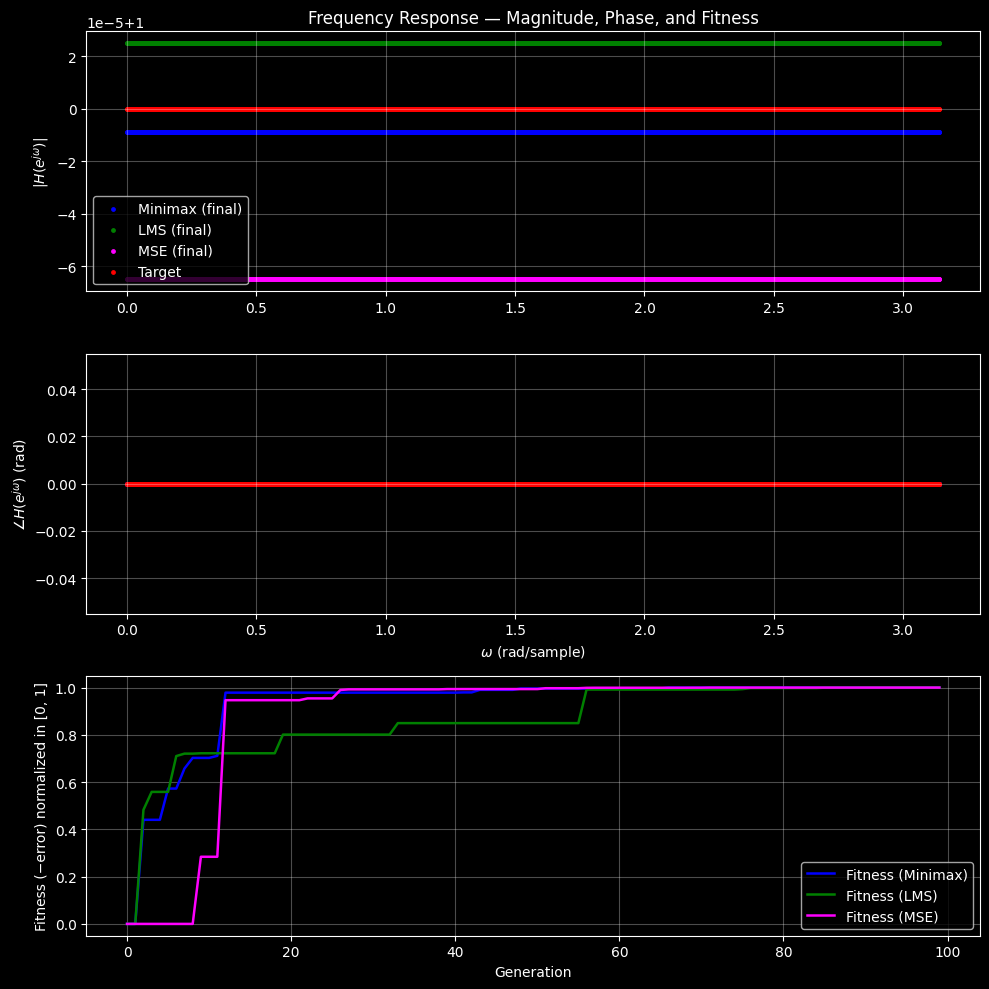

In [329]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


#### 1. Ideal high-pass filter

In [330]:
def target(w):
    return 1 if w >= 1.5 else 0

In [331]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

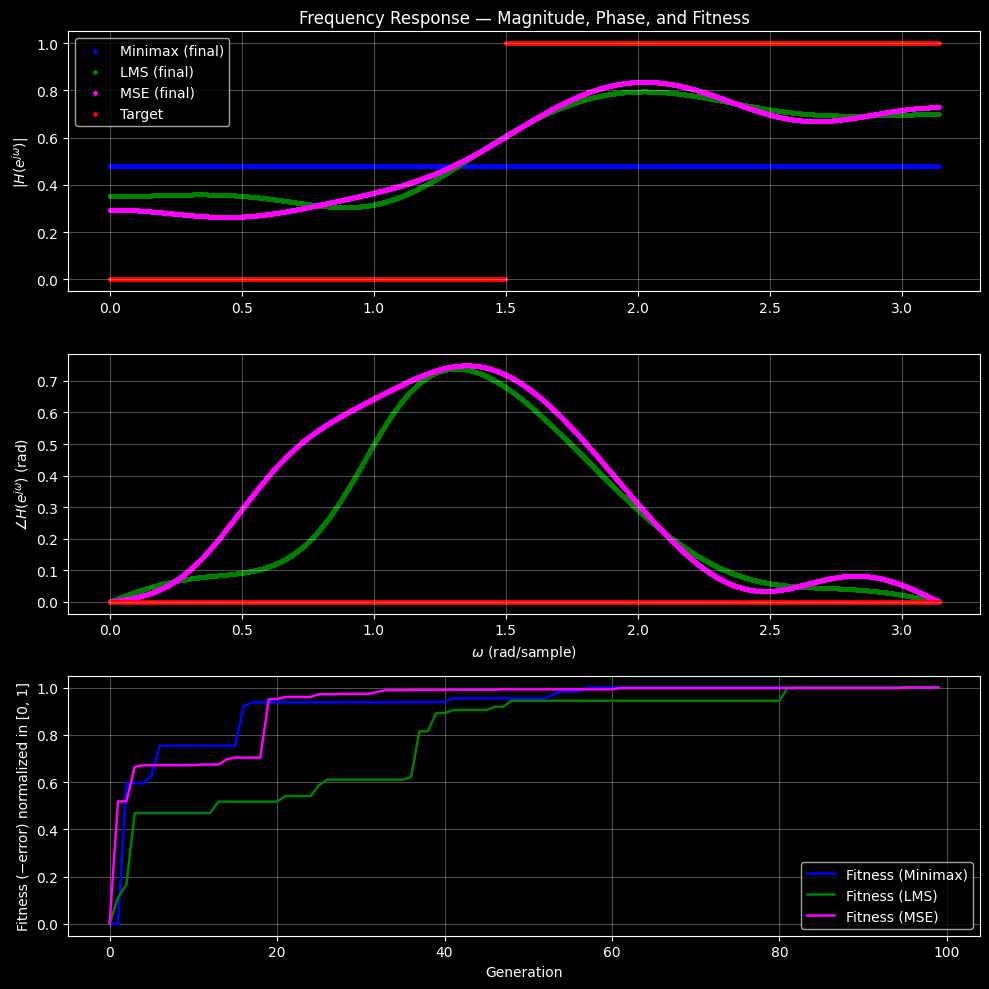

In [332]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


#### 2. Ideal band-pass filter

In [333]:
def target(w):
    return 0 if w >= 2 or w <= 1 else 1

In [334]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

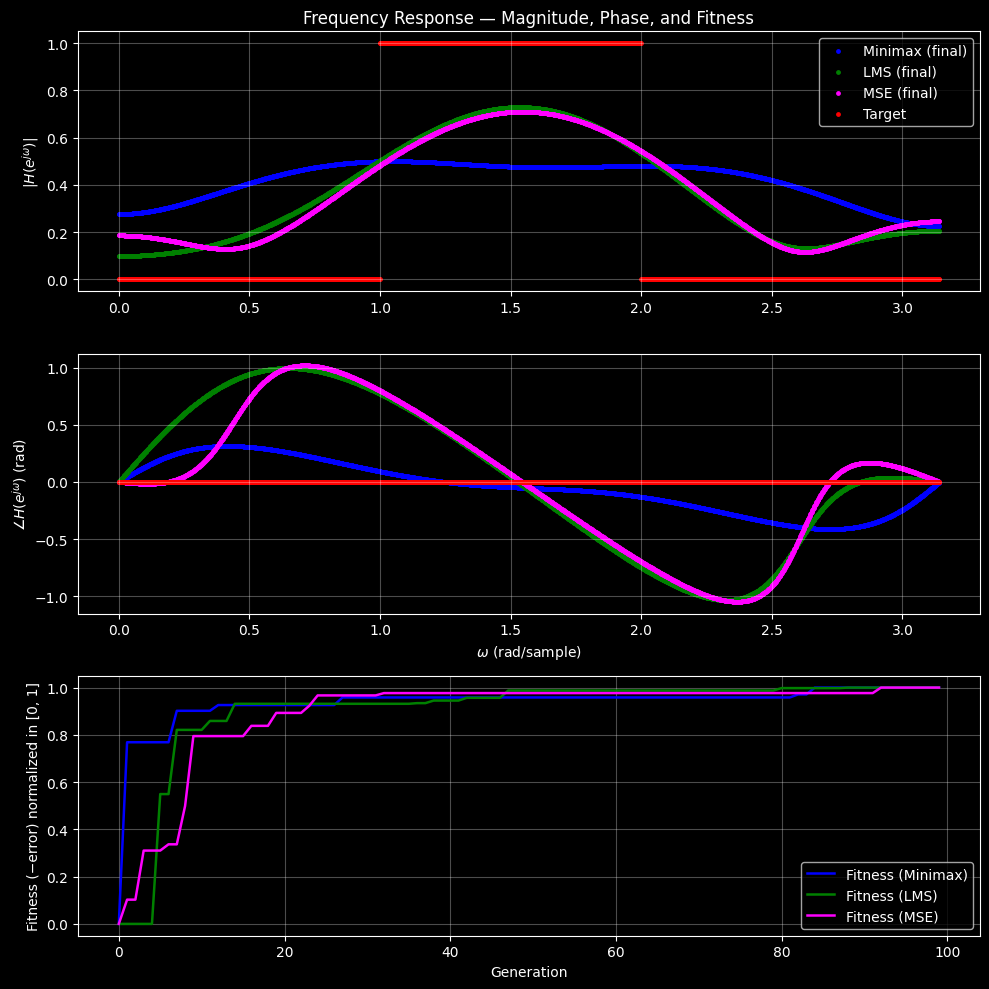

In [335]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


#### 3. Ideal differentiator

In [336]:
def target(w):
    return w

In [337]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

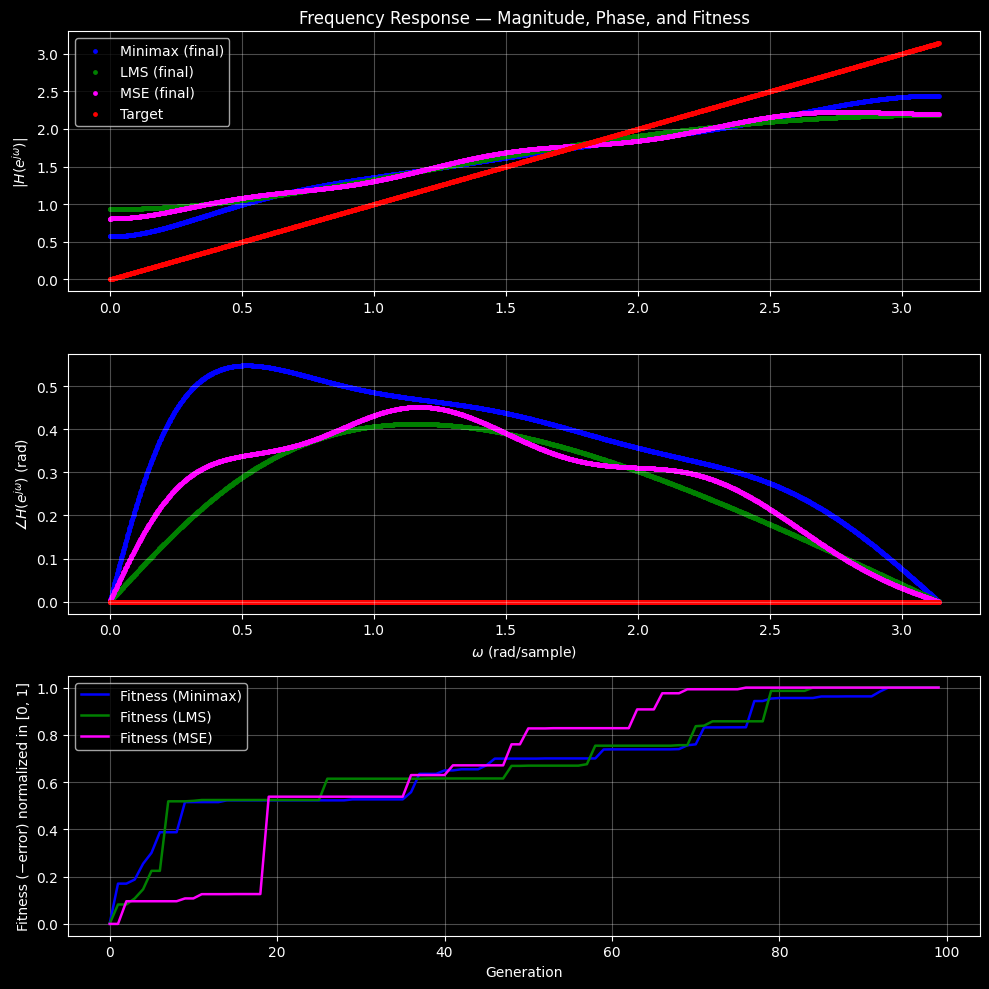

In [338]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 4. Ideal Hilbert Transformer

In [339]:
def target(w):
    if w == 0 or w == np.pi:
        return 0.0
    return -1j

In [340]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

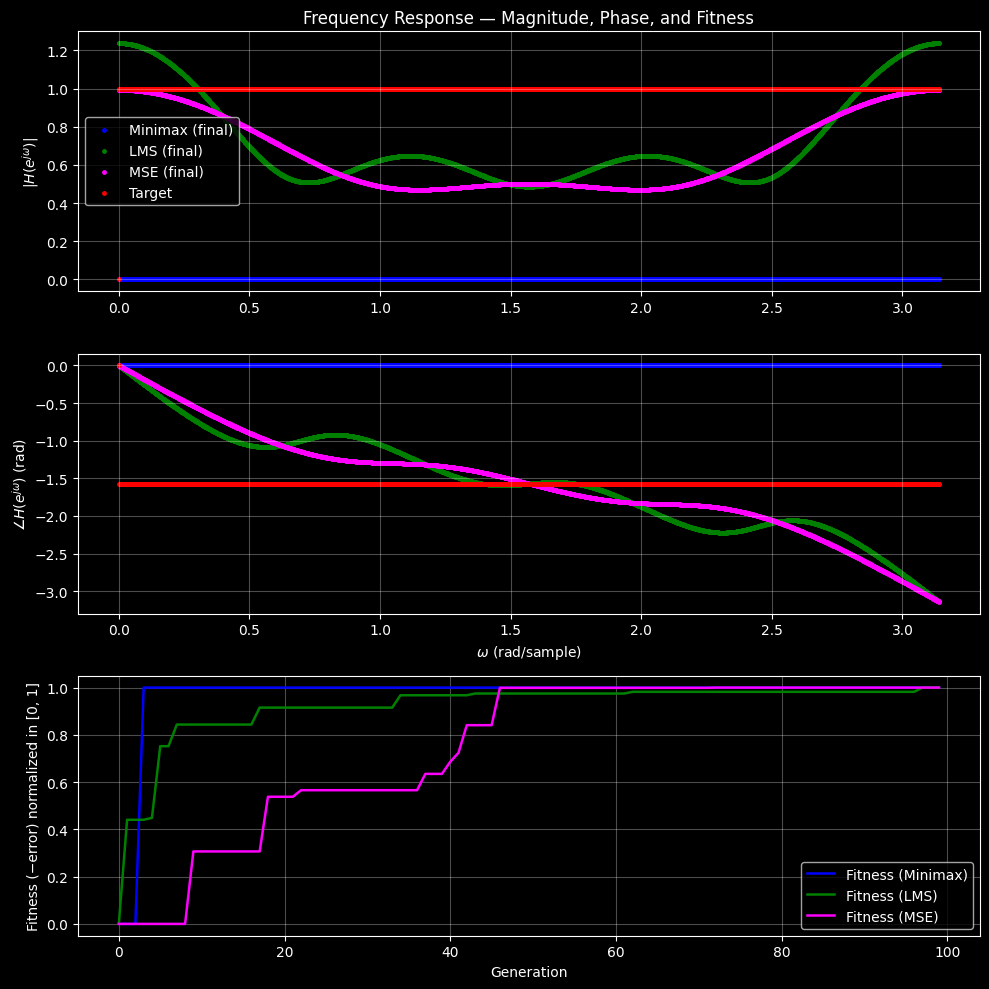

In [341]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 5. Ideal Fractional Delay Filter

In [342]:
def target(w, D=0.4):
    return np.exp(-1j * w * D)

In [343]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

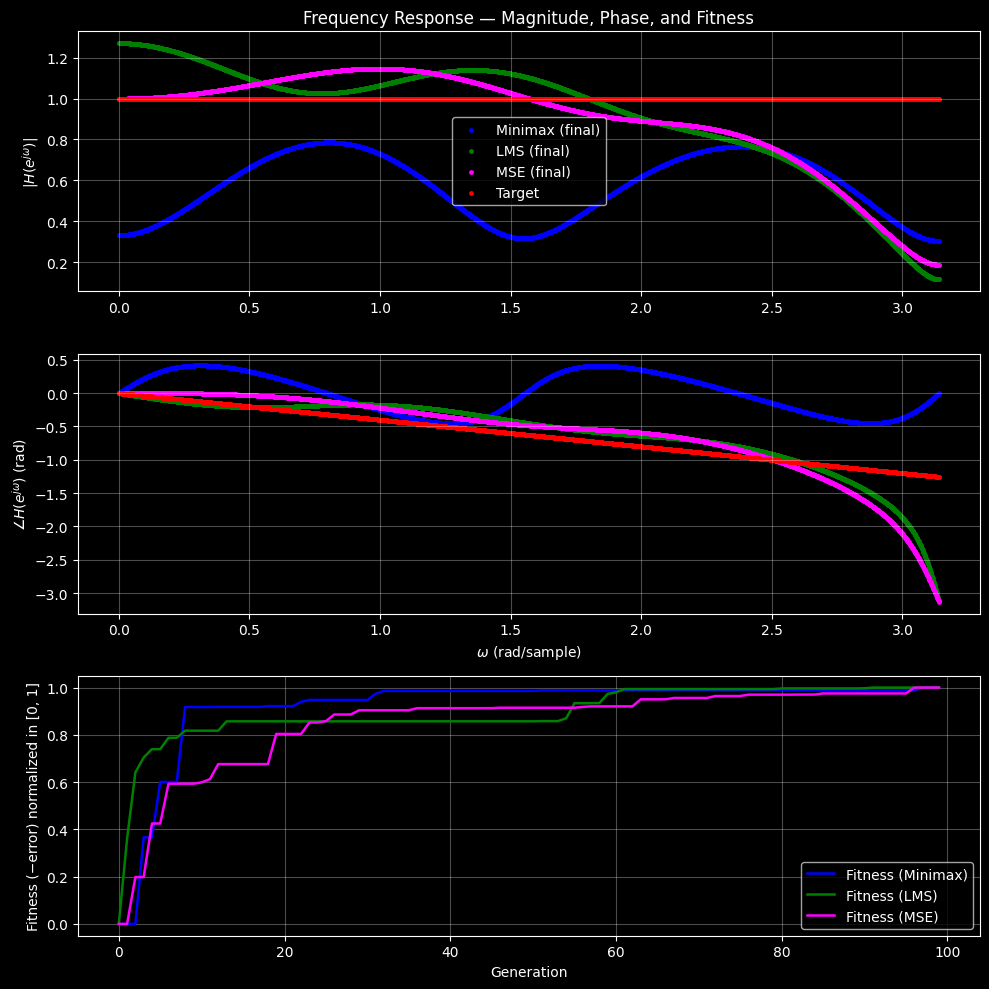

In [344]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 6. Ideal Root‑Raised‑Cosine (RRC) Filter

In [345]:
def target(w, alpha=0.25, ws=np.pi):
    w = abs(w)
    if w <= (1 - alpha) * ws / 2:
        return 1.0
    elif (1 - alpha) * ws / 2 < w <= (1 + alpha) * ws / 2:
        return 0.5 * (1 + np.cos(np.pi/(alpha*ws)*(w - (1-alpha)*ws/2)))
    else:
        return 0.0

In [346]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

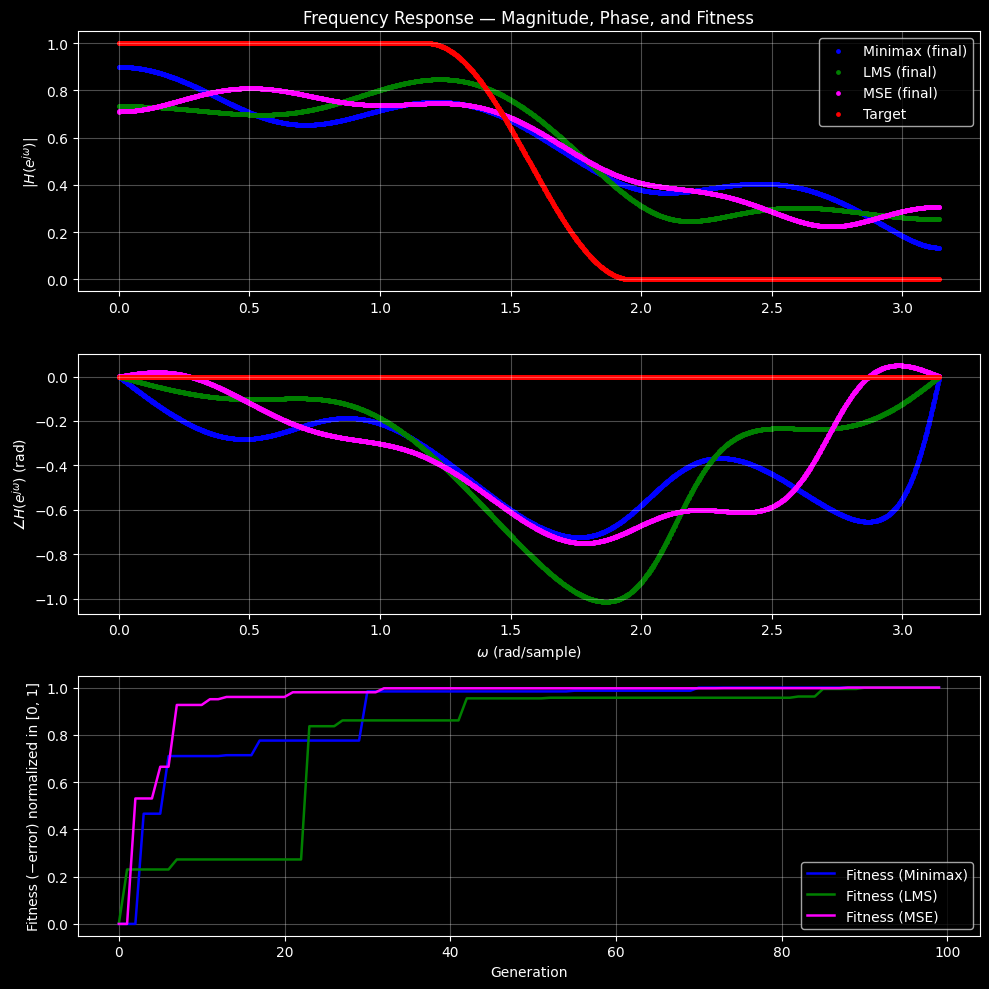

In [347]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 7. Gaussian Low‑Pass Filter

In [348]:
def target(w, sigma=0.5):
    return np.exp(-(sigma**2) * (w**2) / 2)

In [349]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

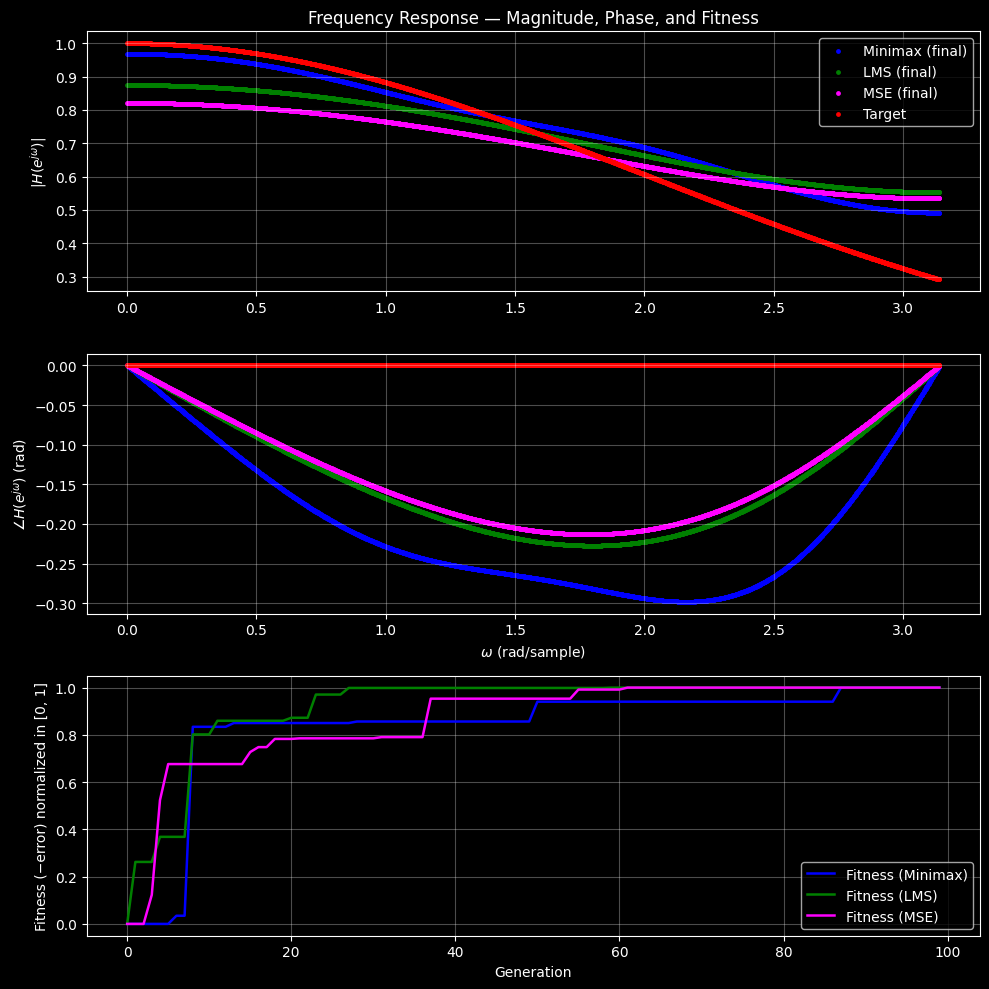

In [350]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 8. Derivative of Gaussian (DoG) Filter

In [351]:
def target(w, sigma=0.5):
    return 1j * w * np.exp(-(sigma**2) * (w**2) / 2)

In [352]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

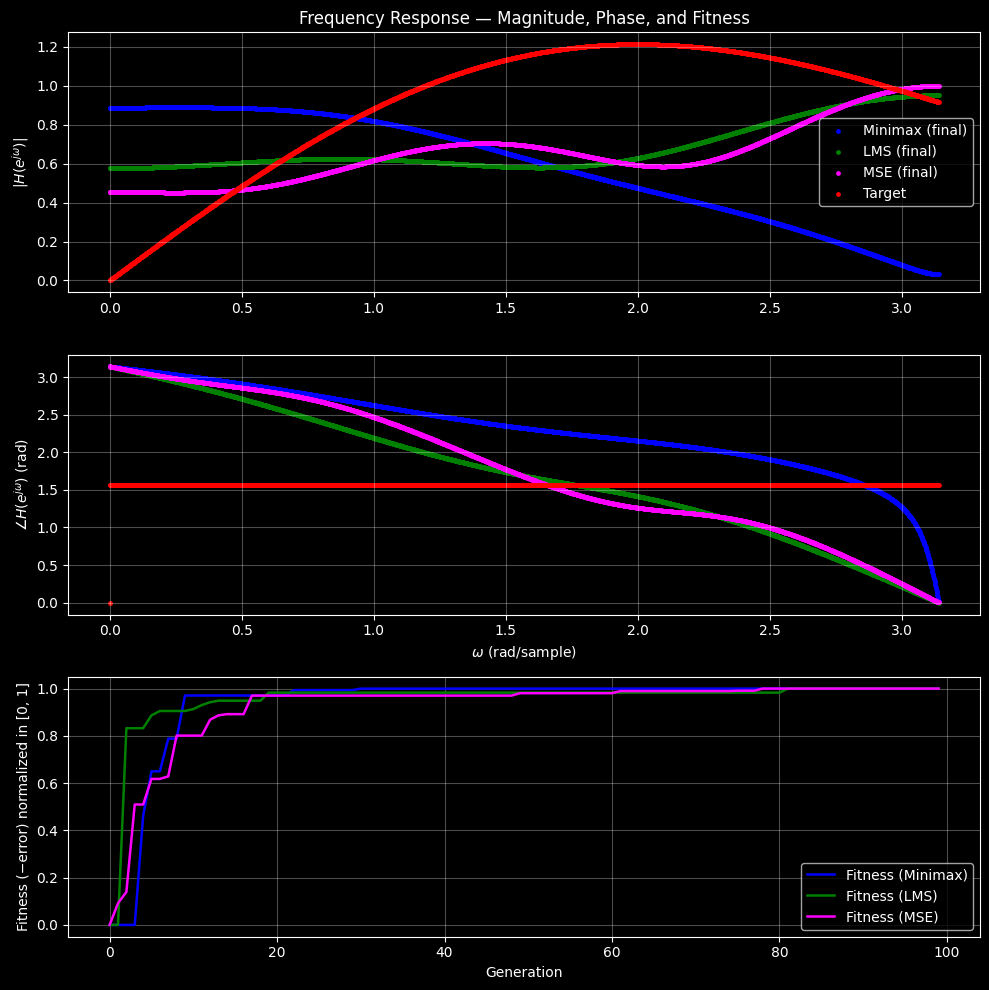

In [353]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 9. Arbitrary Complex Equalizer

In [354]:
def target(w, G=lambda x: -20*np.log10(1 + x)):
    mag = 10**(G(w) / 20.0)
    return mag

In [355]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

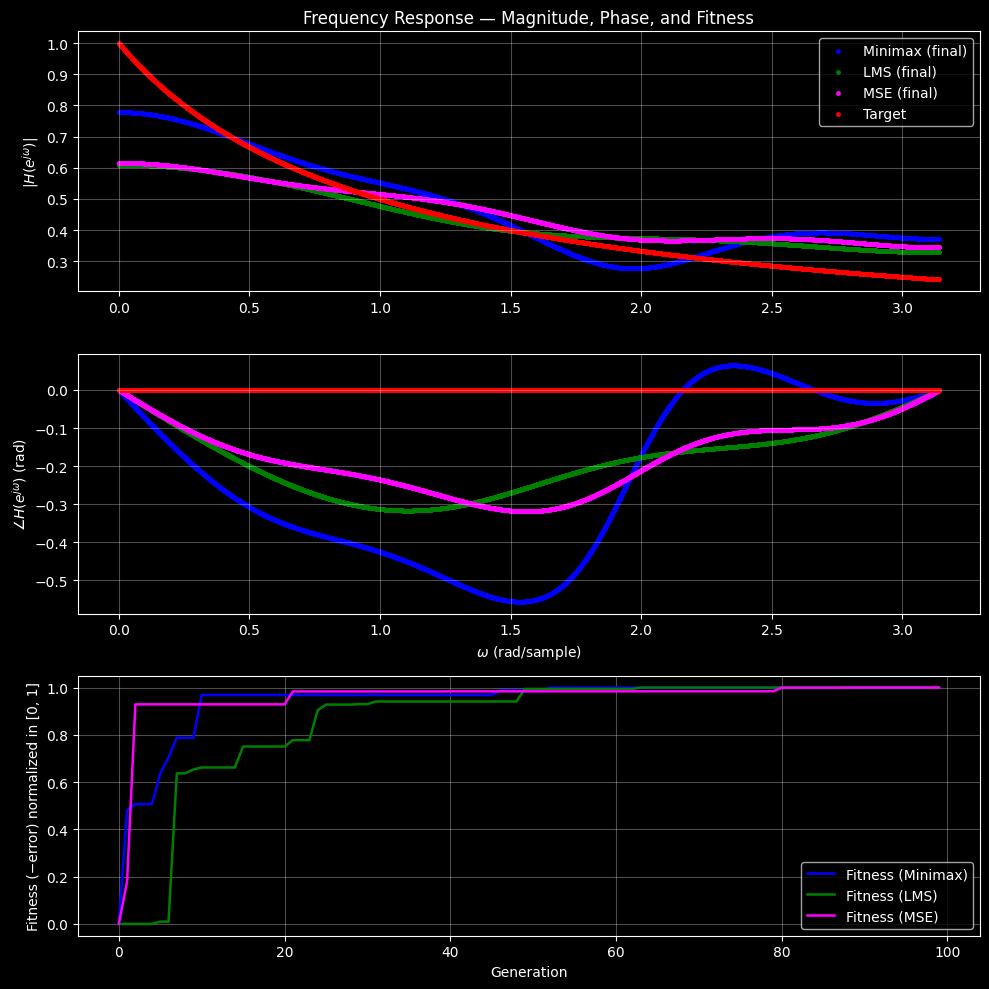

In [356]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()


### 10. Multiband Filter (example: pass–stop–pass)

In [357]:
def target(w, bands=None):
    if bands is None:
        bands = [(0, np.pi / 4), (np.pi / 2, 3 * np.pi / 4)]
    for (a, b) in bands:
        if a <= w <= b:
            return 1.0
    return 0.0

In [358]:
best_minimax = GA(n_pop, generations, order, target, minimax_fit, elitism=True)
best_lms = GA(n_pop, generations, order, target, lms_fit, elitism=True)
best_mse = GA(n_pop, generations, order, target, mse_fit, elitism=True)

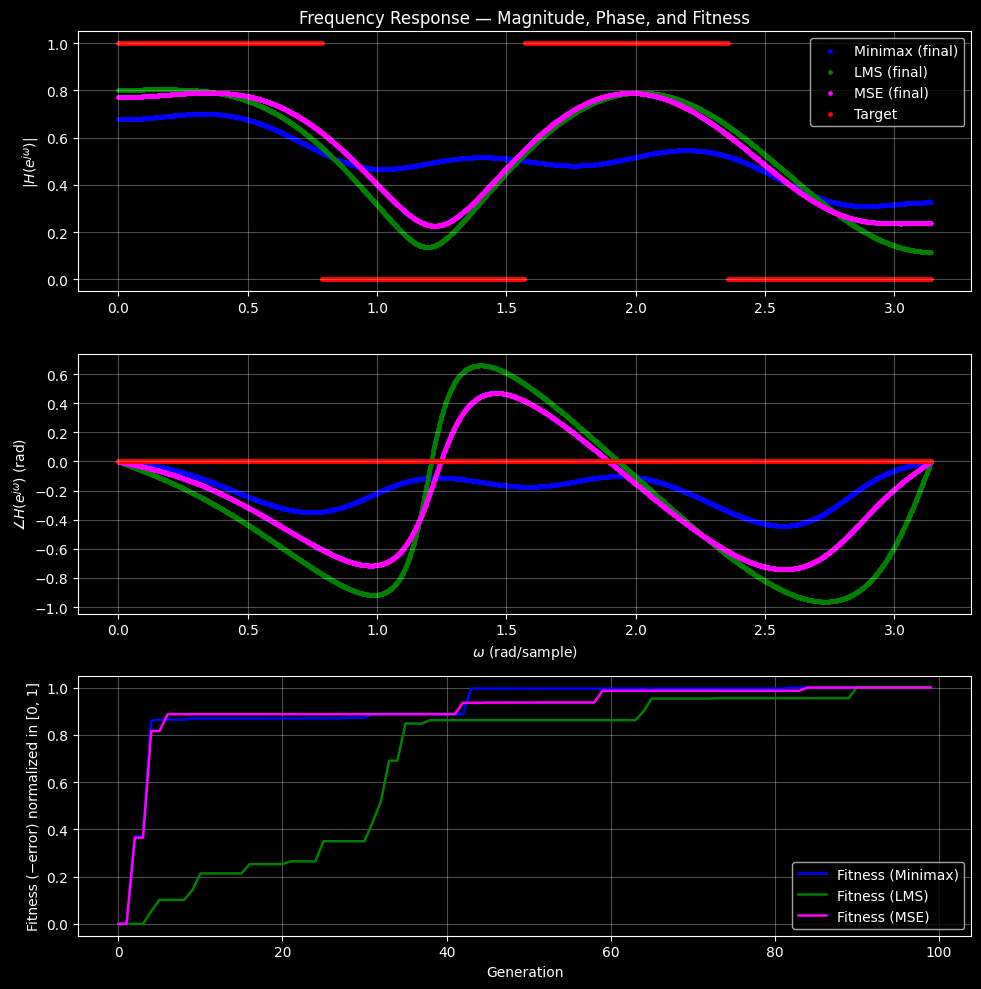

In [359]:
# -----------------------
# Compute frequency responses on a common grid
# -----------------------
worN = 2048  # frequency samples
# Final best individuals (last generation)
b_minimax = best_minimax[-1]
b_lms     = best_lms[-1]
b_mse     = best_mse[-1]

w, H_minimax = freqz(b_minimax, worN=worN)
_, H_lms     = freqz(b_lms,     worN=worN)
_, H_mse     = freqz(b_mse,     worN=worN)

# Target on the same grid (complex)
Ht = np.array([target(wi) for wi in w])

# Magnitude (linear, like your original scatter)
mag_minimax = np.abs(H_minimax)
mag_lms     = np.abs(H_lms)
mag_mse     = np.abs(H_mse)
mag_tgt     = np.abs(Ht)

# Phase (unwrap to remove ±π jumps)
ph_minimax = np.unwrap(np.angle(H_minimax))
ph_lms     = np.unwrap(np.angle(H_lms))
ph_mse     = np.unwrap(np.angle(H_mse))
ph_tgt     = np.unwrap(np.angle(Ht))

# -----------------------
# Fitness histories (negative error type ⇒ larger is better)
# If your GA already stored fitness values, use those instead.
# Otherwise, recompute from the stored best individuals per generation.
# -----------------------
def normalize(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

fit_hist_minimax = normalize([minimax_fit(b, target) for b in best_minimax])
fit_hist_lms     = normalize([lms_fit(b, target)     for b in best_lms])
fit_hist_mse     = normalize([mse_fit(b, target)     for b in best_mse])

gens = np.arange(len(fit_hist_minimax))  # assumes same length; adjust if needed

# -----------------------
# Plot: 3 stacked subplots (Magnitude, Phase, Fitness)
# -----------------------
fig, (ax_mag, ax_phase, ax_fit) = plt.subplots(3, 1, figsize=(10, 10), sharex=False)

# ---- Magnitude subplot ----
ax_mag.scatter(w, mag_minimax, s=6, c='blue',   label='Minimax (final)')
ax_mag.scatter(w, mag_lms,     s=6, c='green',  label='LMS (final)')
ax_mag.scatter(w, mag_mse,     s=6, c='magenta',label='MSE (final)')
ax_mag.scatter(w, mag_tgt,     s=6, c='red',    label='Target')
ax_mag.set_ylabel(r'$|H(e^{j\omega})|$')
ax_mag.set_title('Frequency Response — Magnitude, Phase, and Fitness')
ax_mag.grid(True, alpha=0.3)
ax_mag.legend(loc='best')

# ---- Phase subplot ----
ax_phase.scatter(w, ph_minimax, s=6, c='blue',   label='Minimax (final)')
ax_phase.scatter(w, ph_lms,     s=6, c='green',  label='LMS (final)')
ax_phase.scatter(w, ph_mse,     s=6, c='magenta',label='MSE (final)')
ax_phase.scatter(w, ph_tgt,     s=6, c='red',    label='Target')
ax_phase.set_xlabel(r'$\omega$ (rad/sample)')
ax_phase.set_ylabel(r'$\angle H(e^{j\omega})$ (rad)')
ax_phase.grid(True, alpha=0.3)

# ---- Fitness subplot ----
ax_fit.plot(gens, fit_hist_minimax, color='blue',   linewidth=1.8, label='Fitness (Minimax)')
ax_fit.plot(gens, fit_hist_lms,     color='green',  linewidth=1.8, label='Fitness (LMS)')
ax_fit.plot(gens, fit_hist_mse,     color='magenta',linewidth=1.8, label='Fitness (MSE)')
ax_fit.set_xlabel('Generation')
ax_fit.set_ylabel('Fitness (−error) normalized in [0, 1]')
ax_fit.grid(True, alpha=0.3)
ax_fit.legend(loc='best')

plt.tight_layout()
plt.show()
